# Problem 2 FNO


## Imports


In [19]:
import copy
import itertools
import json
from pathlib import Path
from time import time
import datetime

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as Data
import torch.nn.functional as F


## Configuration


In [20]:
MODEL_NAME = 'darcy_fno'
RANDOM_SEED = 1234
TRAIN_PATH = Path('Coursework2/Coursework2_Problem_2/Darcy_2D_data_train.mat')
TEST_PATH = Path('Coursework2/Coursework2_Problem_2/Darcy_2D_data_test.mat')

RUN_GRID_SEARCH = False
USE_VALIDATION_SPLIT = True
VAL_FRACTION = 0.15
RETRAIN_ON_FULL_TRAIN = True

# Best grid-search config: modes=8, width=32, learning_rate=5e-4, weight_decay=1e-6
BATCH_SIZE = 20
EPOCHS = 500
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-6
USE_SCHEDULER = True
LR_STEP_SIZE = 150
LR_GAMMA = 0.5

MODES = 8
WIDTH = 32
GRID_MODES = [8, 12]
GRID_WIDTHS = [24, 32]
GRID_LEARNING_RATES = [1e-3, 5e-4]

TEST_SAMPLE_INDEX = 0
PRINT_EVERY = 10
SAVE_FIGURES = True
FIGURE_DPI = 200

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
)
print(f'Using device: {device}')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

RUN_GROUP_DIR = Path('problem_2_outputs') / MODEL_NAME
RUN_GROUP_DIR.mkdir(parents=True, exist_ok=True)
RUN_NAME = None
RUN_TIMESTAMP = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_STAGE = 'grid' if RUN_GRID_SEARCH else 'single'
RUN_PHASE = 'final' if RETRAIN_ON_FULL_TRAIN else 'development'
ACTIVE_RUN_NAME = RUN_NAME or f'{RUN_TIMESTAMP}_{RUN_STAGE}_{RUN_PHASE}'
RUN_DIR = RUN_GROUP_DIR / ACTIVE_RUN_NAME
FIGURE_DIR = RUN_DIR / 'figures'
WEIGHT_DIR = RUN_DIR / 'weights'
METRICS_DIR = RUN_DIR / 'metrics'
for path in [FIGURE_DIR, WEIGHT_DIR, METRICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = WEIGHT_DIR / 'best_validation_model.pt'
FINAL_MODEL_PATH = WEIGHT_DIR / 'final_model.pt'
RUN_CONFIG_PATH = RUN_DIR / 'config.json'
METRICS_PATH = METRICS_DIR / 'metrics.json'
GRID_RESULTS_PATH = METRICS_DIR / 'grid_search_results.json'
LOSS_HISTORY_PATH = METRICS_DIR / 'loss_history.npz'
RUN_SUMMARY_PATH = RUN_GROUP_DIR / 'run_summary.jsonl'
LOSS_FIGURE_PATH = FIGURE_DIR / 'loss_curve.png'
PREDICTION_FIGURE_PATH = FIGURE_DIR / 'prediction_comparison.png'
TEST_SAMPLE_FIGURE_PATH = FIGURE_DIR / 'test_sample_truth_prediction.png'


Using device: mps


## Define protocols


In [21]:
# Define Lp loss
class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]
        h = 1.0 / (x.size()[1] - 1.0)
        all_norms = (h ** (self.d / self.p)) * torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)

        return diff_norms / y_norms

    def forward(self, x, y):
        return self.rel(x, y)

    def __call__(self, x, y):
        return self.forward(x, y)


# Define data reader
class MatRead(object):
    def __init__(self, file_path):
        super(MatRead).__init__()

        self.file_path = file_path
        self.data = h5py.File(self.file_path)

    def get_a(self):
        a_field = np.array(self.data['a_field']).T
        return torch.tensor(a_field, dtype=torch.float32)

    def get_u(self):
        u_field = np.array(self.data['u_field']).T
        return torch.tensor(u_field, dtype=torch.float32)


# Define normalizer, pointwise gaussian
class UnitGaussianNormalizer(object):
    def __init__(self, x, eps=0.00001):
        super(UnitGaussianNormalizer, self).__init__()

        self.mean = torch.mean(x, 0)
        self.std = torch.std(x, 0)
        self.eps = eps

    def encode(self, x):
        x = (x - self.mean) / (self.std + self.eps)
        return x

    def decode(self, x):
        x = (x * (self.std + self.eps)) + self.mean
        return x

    def to(self, device):
        self.mean = self.mean.to(device)
        self.std = self.std.to(device)
        return self


## Define network


In [22]:
# Define network
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat)
        )

    def compl_mul2d(self, input, weights):
        return torch.einsum('bixy,ioxy->boxy', input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=x_ft.dtype,
            device=x.device,
        )
        out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, : self.modes1, : self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1 :, : self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1 :, : self.modes2], self.weights2
        )

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x


class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP, self).__init__()
        self.mlp1 = nn.Conv2d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv2d(mid_channels, out_channels, 1)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.mlp1(x)
        x = self.act(x)
        x = self.mlp2(x)
        return x


class FNO(nn.Module):
    def __init__(self, modes1, modes2, width):
        super(FNO, self).__init__()

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width

        self.p = nn.Linear(3, self.width)
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.mlp0 = MLP(self.width, self.width, self.width)
        self.mlp1 = MLP(self.width, self.width, self.width)
        self.mlp2 = MLP(self.width, self.width, self.width)
        self.mlp3 = MLP(self.width, self.width, self.width)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)
        self.act0 = nn.GELU()
        self.act1 = nn.GELU()
        self.act2 = nn.GELU()
        self.q = MLP(self.width, 1, self.width * 4)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x.unsqueeze(-1), grid), dim=-1)
        x = self.p(x)
        x = x.permute(0, 3, 1, 2)

        x1 = self.conv0(x)
        x1 = self.mlp0(x1)
        x2 = self.w0(x)
        x = x1 + x2
        x = self.act0(x)

        x1 = self.conv1(x)
        x1 = self.mlp1(x1)
        x2 = self.w1(x)
        x = x1 + x2
        x = self.act1(x)

        x1 = self.conv2(x)
        x1 = self.mlp2(x1)
        x2 = self.w2(x)
        x = x1 + x2
        x = self.act2(x)

        x1 = self.conv3(x)
        x1 = self.mlp3(x1)
        x2 = self.w3(x)
        x = x1 + x2

        x = self.q(x)
        x = x.squeeze(1)
        return x

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.linspace(0, 1, size_x, dtype=torch.float32, device=device)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat(batchsize, 1, size_y, 1)
        gridy = torch.linspace(0, 1, size_y, dtype=torch.float32, device=device)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat(batchsize, size_x, 1, 1)
        return torch.cat((gridx, gridy), dim=-1)


def build_model(config):
    modes = config['modes']
    width = config['width']
    return FNO(modes, modes, width).to(device)


## Data processing


In [23]:
############################# Data processing #############################
train_path = str(TRAIN_PATH)
test_path = str(TEST_PATH)

data_reader = MatRead(train_path)
a_train = data_reader.get_a()
u_train = data_reader.get_u()

data_reader = MatRead(test_path)
a_test = data_reader.get_a()
u_test = data_reader.get_u()

# Normalize data
a_normalizer = UnitGaussianNormalizer(a_train)
a_train = a_normalizer.encode(a_train)
a_test = a_normalizer.encode(a_test)

u_normalizer = UnitGaussianNormalizer(u_train).to(device)

print('a_train:', a_train.shape)
print('a_test:', a_test.shape)
print('u_train:', u_train.shape)
print('u_test:', u_test.shape)


a_train: torch.Size([1000, 32, 32])
a_test: torch.Size([100, 32, 32])
u_train: torch.Size([1000, 32, 32])
u_test: torch.Size([100, 32, 32])


## Define and train network


In [24]:
############################# Define and train network #############################
loss_func = LpLoss()
batch_size = BATCH_SIZE
epochs = EPOCHS

def build_configurations():
    base_config = {
        'modes': MODES,
        'width': WIDTH,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
    }
    if not RUN_GRID_SEARCH:
        return [base_config]

    configurations = []
    for modes, width, learning_rate in itertools.product(
        GRID_MODES, GRID_WIDTHS, GRID_LEARNING_RATES
    ):
        configurations.append(
            {
                'modes': int(modes),
                'width': int(width),
                'learning_rate': float(learning_rate),
                'weight_decay': float(WEIGHT_DECAY),
            }
        )
    return configurations


def split_train_validation(a_train_tensor, u_train_tensor):
    if not USE_VALIDATION_SPLIT:
        return a_train_tensor, u_train_tensor, None, None

    num_samples = a_train_tensor.shape[0]
    val_count = max(1, int(num_samples * VAL_FRACTION))
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    permutation = torch.randperm(num_samples, generator=generator)
    val_index = permutation[:val_count]
    train_index = permutation[val_count:]
    return (
        a_train_tensor[train_index],
        u_train_tensor[train_index],
        a_train_tensor[val_index],
        u_train_tensor[val_index],
    )


def evaluate_model(net, input_tensor, target_tensor):
    net.eval()
    with torch.no_grad():
        output = net(input_tensor.to(device))
        output = u_normalizer.decode(output)
        loss = loss_func(output, target_tensor.to(device)).item()
    return loss


def train_configuration(config, run_final_training=False):
    net = build_model(config)
    n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

    optimizer = torch.optim.Adam(
        net.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay']
    )
    scheduler = None
    if USE_SCHEDULER:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

    if run_final_training:
        a_train_run = a_train
        u_train_run = u_train
        a_eval = a_test
        u_eval = u_test
        eval_name = 'test'
    else:
        a_train_run, u_train_run, a_val, u_val = split_train_validation(a_train, u_train)
        if a_val is None:
            a_eval = a_test
            u_eval = u_test
            eval_name = 'test'
        else:
            a_eval = a_val
            u_eval = u_val
            eval_name = 'validation'

    train_set = Data.TensorDataset(a_train_run, u_train_run)
    train_loader = Data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

    loss_train_list = []
    loss_eval_list = []
    x = []
    best_eval_loss = float('inf')
    best_state_dict = None
    start_time = time()

    for epoch in range(epochs):
        net.train(True)
        trainloss = 0.0
        for input, target in train_loader:
            input = input.to(device)
            target = target.to(device)

            output = net(input)
            output = u_normalizer.decode(output)
            l = loss_func(output, target)

            optimizer.zero_grad()
            l.backward()
            optimizer.step()

            trainloss += l.item()

        trainloss = trainloss / len(train_loader)
        if scheduler is not None:
            scheduler.step()

        evalloss = evaluate_model(net, a_eval, u_eval)

        if not run_final_training and evalloss < best_eval_loss:
            best_eval_loss = evalloss
            best_state_dict = copy.deepcopy(net.state_dict())

        if epoch % PRINT_EVERY == 0 or epoch == epochs - 1:
            print(
                f"epoch:{epoch + 1}, train loss:{trainloss:.6f}, {eval_name} loss:{evalloss:.6f}"
            )

        loss_train_list.append(trainloss)
        loss_eval_list.append(evalloss)
        x.append(epoch + 1)

    total_time = time() - start_time
    total_time_str = str(datetime.timedelta(seconds=int(total_time)))

    if not run_final_training and best_state_dict is not None:
        net.load_state_dict(best_state_dict)

    result = {
        'config': config,
        'net': net,
        'n_params': n_params,
        'loss_train_list': loss_train_list,
        'loss_eval_list': loss_eval_list,
        'x': x,
        'eval_name': eval_name,
        'training_time': total_time_str,
        'final_train_loss': loss_train_list[-1],
        'final_eval_loss': loss_eval_list[-1],
        'best_eval_loss': best_eval_loss if best_state_dict is not None else loss_eval_list[-1],
        'best_state_dict': best_state_dict,
    }
    return result


configurations = build_configurations()
print(f'Number of candidate configurations: {len(configurations)}')

grid_search_results = []
best_development_result = None
best_config = None

for idx, config in enumerate(configurations, start=1):
    print(f'Running configuration {idx}/{len(configurations)}: {config}')
    development_result = train_configuration(config, run_final_training=False)
    result_summary = {
        'config': config,
        'n_params': development_result['n_params'],
        'best_validation_loss': development_result['best_eval_loss'],
        'final_validation_loss': development_result['final_eval_loss'],
        'training_time': development_result['training_time'],
    }
    grid_search_results.append(result_summary)

    if best_development_result is None or development_result['best_eval_loss'] < best_development_result['best_eval_loss']:
        best_development_result = development_result
        best_config = config

with open(GRID_RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(grid_search_results, f, indent=2)

if best_development_result is not None and best_development_result['best_state_dict'] is not None:
    torch.save(best_development_result['best_state_dict'], BEST_MODEL_PATH)

print(f'Selected configuration: {best_config}')

if RETRAIN_ON_FULL_TRAIN:
    print('Retraining selected configuration on the full training set...')
    active_result = train_configuration(best_config, run_final_training=True)
    torch.save(active_result['net'].state_dict(), FINAL_MODEL_PATH)
    plot_mode = 'final'
else:
    active_result = best_development_result
    plot_mode = 'development'

trained_net = active_result['net']
selected_config = best_config
n_params = active_result['n_params']
loss_train_list = active_result['loss_train_list']
loss_eval_list = active_result['loss_eval_list']
x = active_result['x']
plot_label = 'Test loss' if plot_mode == 'final' else 'Validation loss'

metrics = {
    'model_name': MODEL_NAME,
    'device': str(device),
    'run_grid_search': RUN_GRID_SEARCH,
    'use_validation_split': USE_VALIDATION_SPLIT,
    'retrain_on_full_train': RETRAIN_ON_FULL_TRAIN,
    'selected_config': selected_config,
    'n_params': n_params,
    'training_time': active_result['training_time'],
    'final_train_loss': active_result['final_train_loss'],
    'final_eval_loss': active_result['final_eval_loss'],
    'best_validation_loss': best_development_result['best_eval_loss'] if best_development_result is not None else None,
    'grid_search_results_path': str(GRID_RESULTS_PATH),
}

if plot_mode == 'final':
    testloss = evaluate_model(trained_net, a_test, u_test)
    metrics['final_test_loss'] = testloss
    trained_net.eval()
    with torch.no_grad():
        sample_input = a_test[TEST_SAMPLE_INDEX:TEST_SAMPLE_INDEX + 1].to(device)
        sample_prediction = trained_net(sample_input)
        sample_prediction = u_normalizer.decode(sample_prediction).cpu().squeeze(0)
    sample_truth = u_test[TEST_SAMPLE_INDEX]
    sample_error = torch.abs(sample_prediction - sample_truth)
else:
    sample_prediction = None
    sample_truth = None
    sample_error = None

loss_history = {
    'epoch': np.array(x, dtype=np.int32),
    'train_loss': np.array(loss_train_list, dtype=np.float32),
    'eval_loss': np.array(loss_eval_list, dtype=np.float32),
}
np.savez(LOSS_HISTORY_PATH, **loss_history)

run_config = {
    'model_name': MODEL_NAME,
    'run_name': ACTIVE_RUN_NAME,
    'device': str(device),
    'random_seed': RANDOM_SEED,
    'train_path': str(TRAIN_PATH),
    'test_path': str(TEST_PATH),
    'run_grid_search': RUN_GRID_SEARCH,
    'use_validation_split': USE_VALIDATION_SPLIT,
    'val_fraction': VAL_FRACTION,
    'retrain_on_full_train': RETRAIN_ON_FULL_TRAIN,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'use_scheduler': USE_SCHEDULER,
    'lr_step_size': LR_STEP_SIZE,
    'lr_gamma': LR_GAMMA,
    'modes': MODES,
    'width': WIDTH,
    'grid_search_space': {
        'modes': GRID_MODES,
        'width': GRID_WIDTHS,
        'learning_rate': GRID_LEARNING_RATES,
    },
    'selected_config': selected_config,
    'test_sample_index': TEST_SAMPLE_INDEX,
    'plot_mode': plot_mode,
}

metrics['run_name'] = ACTIVE_RUN_NAME
metrics['run_dir'] = str(RUN_DIR)
metrics['loss_history_path'] = str(LOSS_HISTORY_PATH)
metrics['run_config_path'] = str(RUN_CONFIG_PATH)
metrics['best_model_path'] = str(BEST_MODEL_PATH) if BEST_MODEL_PATH.exists() else None
metrics['final_model_path'] = str(FINAL_MODEL_PATH) if FINAL_MODEL_PATH.exists() else None
metrics['loss_figure_path'] = str(LOSS_FIGURE_PATH)
metrics['prediction_figure_path'] = str(PREDICTION_FIGURE_PATH) if plot_mode == 'final' else None

with open(RUN_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(run_config, f, indent=2)

with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

run_summary = {
    'run_name': ACTIVE_RUN_NAME,
    'plot_mode': plot_mode,
    'selected_config': selected_config,
    'final_train_loss': active_result['final_train_loss'],
    'final_eval_loss': active_result['final_eval_loss'],
    'final_test_loss': metrics.get('final_test_loss'),
    'training_time': active_result['training_time'],
    'metrics_path': str(METRICS_PATH),
    'config_path': str(RUN_CONFIG_PATH),
}
with open(RUN_SUMMARY_PATH, 'a', encoding='utf-8') as f:
    f.write(json.dumps(run_summary) + '\n')

print(f'Run name: {ACTIVE_RUN_NAME}')
print(f'Number of parameters: {n_params}')
print(f'Selected configuration: {selected_config}')
print(f'Training time: {active_result["training_time"]}')
print(f'Final train loss: {active_result["final_train_loss"]:.6f}')
print(f'{plot_label}: {active_result["final_eval_loss"]:.6f}')


Number of candidate configurations: 1
Running configuration 1/1: {'modes': 8, 'width': 32, 'learning_rate': 0.0005, 'weight_decay': 1e-06}


/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:24: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 32, 32, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft2(x)
/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:41: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [20, 32, 32, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inpl

epoch:1, train loss:0.058665, validation loss:0.057139
epoch:11, train loss:0.041038, validation loss:0.038879
epoch:21, train loss:0.040202, validation loss:0.040180
epoch:31, train loss:0.039443, validation loss:0.038976
epoch:41, train loss:0.038498, validation loss:0.039225
epoch:51, train loss:0.037901, validation loss:0.037811
epoch:61, train loss:0.038467, validation loss:0.038757
epoch:71, train loss:0.037879, validation loss:0.038456
epoch:81, train loss:0.037572, validation loss:0.038066
epoch:91, train loss:0.037974, validation loss:0.039158
epoch:101, train loss:0.038123, validation loss:0.040077
epoch:111, train loss:0.036834, validation loss:0.041899
epoch:121, train loss:0.038781, validation loss:0.037885
epoch:131, train loss:0.039487, validation loss:0.038879
epoch:141, train loss:0.040237, validation loss:0.038722
epoch:151, train loss:0.039723, validation loss:0.039528
epoch:161, train loss:0.040006, validation loss:0.039433
epoch:171, train loss:0.038737, validation

/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:24: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [100, 32, 32, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft2(x)
/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:41: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [100, 32, 32, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, in

epoch:1, train loss:0.059160, test loss:0.050305
epoch:11, train loss:0.040800, test loss:0.044984
epoch:21, train loss:0.041305, test loss:0.040544
epoch:31, train loss:0.043882, test loss:0.041014
epoch:41, train loss:0.041246, test loss:0.040276
epoch:51, train loss:0.038341, test loss:0.037920
epoch:61, train loss:0.042079, test loss:0.044218
epoch:71, train loss:0.048476, test loss:0.049466
epoch:81, train loss:0.045852, test loss:0.044420
epoch:91, train loss:0.045176, test loss:0.043750
epoch:101, train loss:0.043922, test loss:0.042136
epoch:111, train loss:0.043938, test loss:0.042546
epoch:121, train loss:0.045734, test loss:0.043574
epoch:131, train loss:0.042645, test loss:0.041593
epoch:141, train loss:0.043114, test loss:0.042963
epoch:151, train loss:0.039900, test loss:0.039598
epoch:161, train loss:0.038884, test loss:0.039749
epoch:171, train loss:0.038905, test loss:0.039641
epoch:181, train loss:0.038119, test loss:0.039540
epoch:191, train loss:0.038343, test loss:

/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:24: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 32, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft2(x)
/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:41: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 32, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplac

## Plot


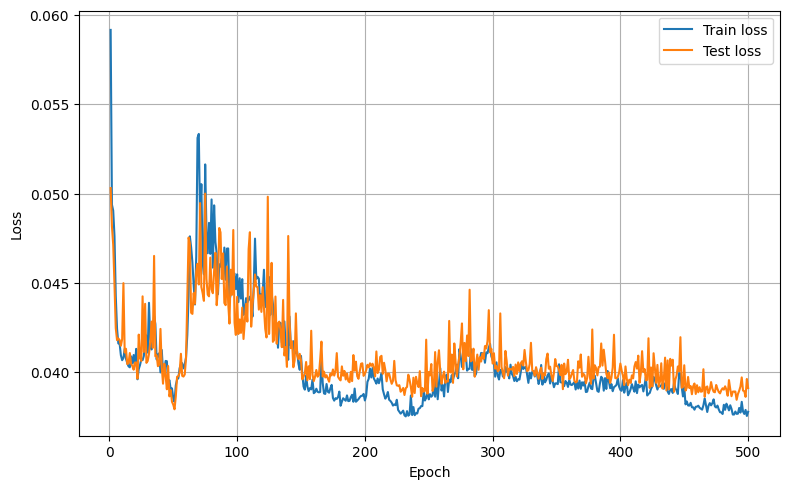

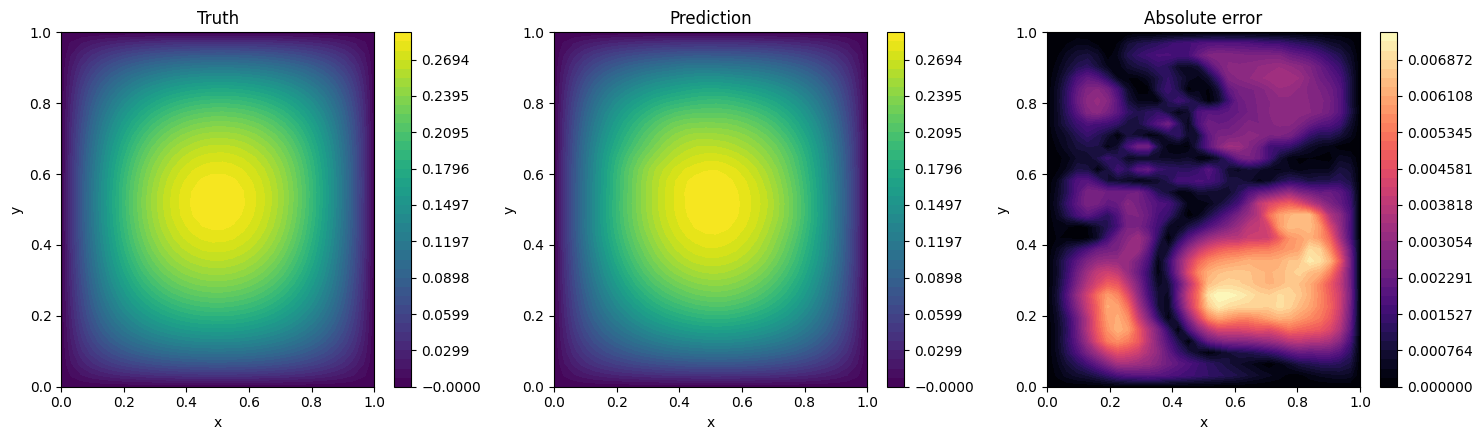

In [25]:
############################# Plot #############################
plt.figure(figsize=(8, 5))
plt.plot(x, loss_train_list, label='Train loss')
plt.plot(x, loss_eval_list, label=plot_label)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(LOSS_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

if plot_mode == 'final':
    grid = np.linspace(0, 1, sample_truth.shape[0])
    X, Y = np.meshgrid(grid, grid, indexing='ij')
    field_min = min(sample_truth.min().item(), sample_prediction.min().item())
    field_max = max(sample_truth.max().item(), sample_prediction.max().item())
    levels = np.linspace(field_min, field_max, 40)
    error_levels = np.linspace(0.0, sample_error.max().item() + 1e-12, 40)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    contour_truth = axes[0].contourf(X, Y, sample_truth.numpy(), levels=levels, cmap='viridis')
    axes[0].set_title('Truth')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    fig.colorbar(contour_truth, ax=axes[0])

    contour_prediction = axes[1].contourf(X, Y, sample_prediction.numpy(), levels=levels, cmap='viridis')
    axes[1].set_title('Prediction')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    fig.colorbar(contour_prediction, ax=axes[1])

    contour_error = axes[2].contourf(X, Y, sample_error.numpy(), levels=error_levels, cmap='magma')
    axes[2].set_title('Absolute error')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('y')
    fig.colorbar(contour_error, ax=axes[2])

    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(PREDICTION_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()


## Test Sample Contours


/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:24: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 32, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft2(x)
/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:41: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 32, 32, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplac

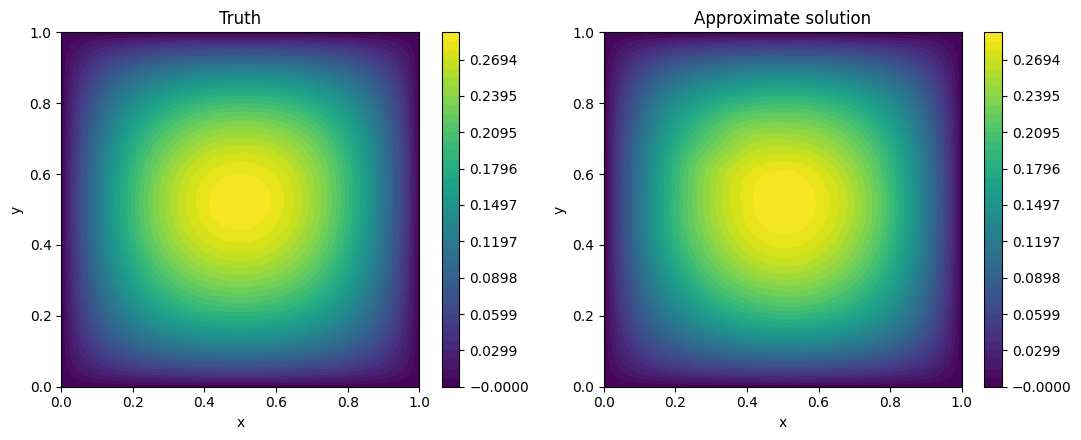

In [26]:
############################# Test sample contours #############################
trained_net.eval()
with torch.no_grad():
    contour_input = a_test[TEST_SAMPLE_INDEX:TEST_SAMPLE_INDEX + 1].to(device)
    contour_prediction = trained_net(contour_input)
    contour_prediction = u_normalizer.decode(contour_prediction).cpu().squeeze(0)

contour_truth = u_test[TEST_SAMPLE_INDEX]
grid = np.linspace(0, 1, contour_truth.shape[0])
X, Y = np.meshgrid(grid, grid, indexing='ij')
field_min = min(contour_truth.min().item(), contour_prediction.min().item())
field_max = max(contour_truth.max().item(), contour_prediction.max().item())
levels = np.linspace(field_min, field_max, 40)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
truth_plot = axes[0].contourf(X, Y, contour_truth.numpy(), levels=levels, cmap='viridis')
axes[0].set_title('Truth')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(truth_plot, ax=axes[0])

prediction_plot = axes[1].contourf(X, Y, contour_prediction.numpy(), levels=levels, cmap='viridis')
axes[1].set_title('Approximate solution')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(prediction_plot, ax=axes[1])

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(TEST_SAMPLE_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()


## Final Test Error


In [27]:
############################# Final test error #############################
final_test_loss = evaluate_model(trained_net, a_test, u_test)
metrics['reported_test_loss'] = final_test_loss
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print(f'Final test relative L2 error: {final_test_loss:.6f}')


Final test relative L2 error: 0.039111


/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:24: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [100, 32, 32, 17]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x_ft = torch.fft.rfft2(x)
/var/folders/9m/5yl447m538l3dw65wfhnx6xh0000gn/T/ipykernel_88307/222657463.py:41: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [100, 32, 32, 32]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, in